# Solar Radiation Forecasting for Al-Zilfi, Saudi Arabia
## A Systematic Model Selection and Regional Calibration Study

**Author:** Roied Alnajran  
**Institution:** King Abdullah University of Science and Technology (KACST)  
**Location studied:** Al-Zilfi, Riyadh Region, Saudi Arabia (26.3°N, 44.8°E, 605m altitude)

---

### Overview

Solar radiation forecasting models developed for temperate climates often perform poorly in 
arid regions like central Saudi Arabia. This study evaluates **52 published global models** 
against 7-year averaged monthly data for Al-Zilfi, and develops a **locally calibrated 
quadratic regression model** that outperforms all 52 global benchmarks.

**Key result:** The locally calibrated quadratic model achieves an RMSE of **0.0189** — 
a 65% improvement over the best-performing global model (JAIN11, RMSE=0.0547).

> ⚠️ **Limitation note:** With 12 monthly data points (7-year averages), high R² values 
> are expected for any smooth regression. Results should be interpreted as a preliminary 
> regional calibration rather than a generalizable model. A larger dataset would strengthen 
> statistical validity.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats, optimize
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Dataset

The dataset consists of 12 monthly values representing **7-year averages** (measured at 
Al-Zilfi meteorological station). The key variables are:

- **H** — Monthly mean daily global solar radiation (kWh/m²/day)  
- **H₀** — Extraterrestrial radiation (kWh/m²/day)  
- **H/H₀** — Clearness index (dimensionless)  
- **S/S₀** — Relative sunshine duration (dimensionless)

In [20]:
# 12-month dataset for Al-Zilfi, Saudi Arabia
# Source: 7-year averaged measurements from Al-Zilfi meteorological station

months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']

H_obs  = np.array([3.973, 5.011, 5.709, 6.036, 6.448, 7.247,
                   7.136, 6.830, 5.962, 4.963, 4.248, 3.628])  # kWh/m²/day

H0     = np.array([6.543, 7.738, 9.190, 10.402, 11.090, 11.316,
                   11.177, 10.644, 9.653, 8.272, 6.902, 6.176])  # kWh/m²/day

H_H0   = H_obs / H0   # Clearness index

S_So   = np.array([0.62, 0.69, 0.67, 0.66, 0.72, 0.85,
                   0.87, 0.85, 0.81, 0.80, 0.70, 0.60])  # Relative sunshine

df = pd.DataFrame({
    'Month': months,
    'H (kWh/m²/day)': H_obs,
    'H₀ (kWh/m²/day)': H0,
    'H/H₀ (Clearness Index)': H_H0.round(4),
    'S/S₀ (Sunshine Ratio)': S_So
})

print(f"Study location: Al-Zilfi, Saudi Arabia")
print(f"Coordinates: 26.3°N, 44.8°E | Altitude: 605m")
print(f"Dataset: {len(months)} monthly averages from 7 years of measurements\n")
print(df.to_string(index=False))

Study location: Al-Zilfi, Saudi Arabia
Coordinates: 26.3°N, 44.8°E | Altitude: 605m
Dataset: 12 monthly averages from 7 years of measurements

Month  H (kWh/m²/day)  H₀ (kWh/m²/day)  H/H₀ (Clearness Index)  S/S₀ (Sunshine Ratio)
  Jan           3.973            6.543                  0.6072                   0.62
  Feb           5.011            7.738                  0.6476                   0.69
  Mar           5.709            9.190                  0.6212                   0.67
  Apr           6.036           10.402                  0.5803                   0.66
  May           6.448           11.090                  0.5814                   0.72
  Jun           7.247           11.316                  0.6404                   0.85
  Jul           7.136           11.177                  0.6385                   0.87
  Aug           6.830           10.644                  0.6417                   0.85
  Sep           5.962            9.653                  0.6176                   0.

## 2. Annual Radiation Profile

Al-Zilfi shows a clear peak in summer months (June–July) driven by maximum sunshine hours, 
with the lowest radiation in winter (December–January).

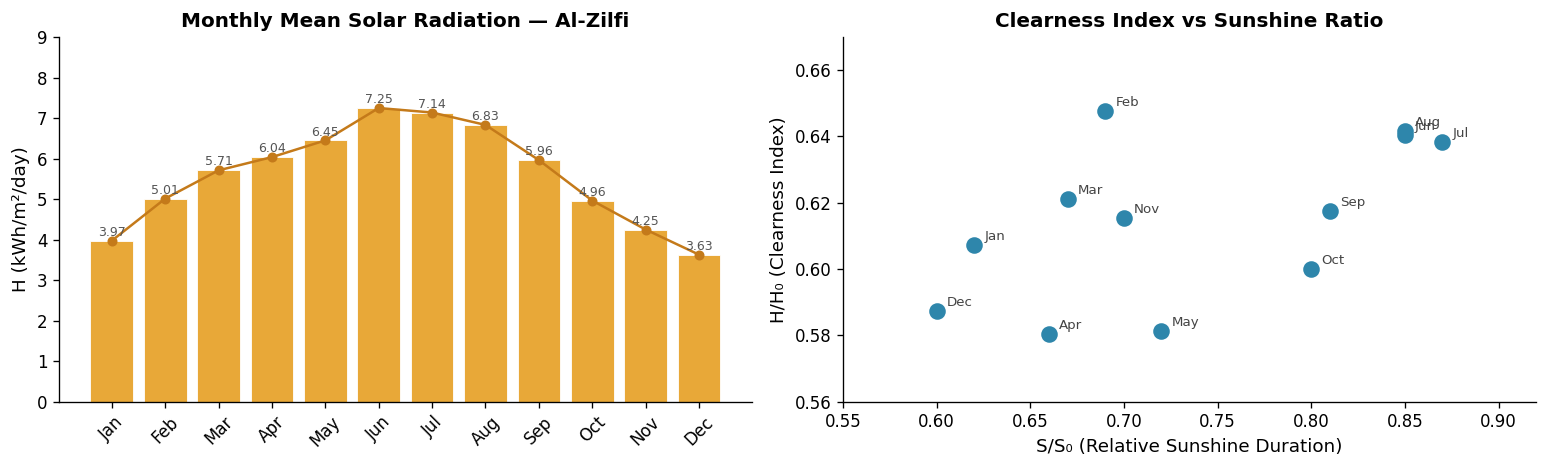

The clearness index (H/H₀) increases with sunshine ratio (S/S₀),
confirming the Ångström-Prescott relationship holds for this region.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel A: Annual cycle of H
ax = axes[0]
ax.bar(months, H_obs, color='#E8A838', edgecolor='white', linewidth=0.5)
ax.plot(months, H_obs, 'o-', color='#C47A1A', markersize=5, linewidth=1.5)
ax.set_ylabel('H (kWh/m²/day)', fontsize=11)
ax.set_title('Monthly Mean Solar Radiation — Al-Zilfi', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(0, 9)
for i, v in enumerate(H_obs):
    ax.text(i, v + 0.12, f'{v:.2f}', ha='center', fontsize=7.5, color='#555')

# Panel B: H/H0 vs S/So scatter
ax = axes[1]
scatter = ax.scatter(S_So, H_H0, color='#2E86AB', s=80, zorder=5)
for i, m in enumerate(months):
    ax.annotate(m, (S_So[i], H_H0[i]), textcoords='offset points',
                xytext=(6, 3), fontsize=8, color='#444')
ax.set_xlabel('S/S₀ (Relative Sunshine Duration)', fontsize=11)
ax.set_ylabel('H/H₀ (Clearness Index)', fontsize=11)
ax.set_title('Clearness Index vs Sunshine Ratio', fontweight='bold')
ax.set_xlim(0.55, 0.92)
ax.set_ylim(0.56, 0.67)

plt.tight_layout()
plt.savefig('annual_profile.png', bbox_inches='tight')
plt.show()
print("The clearness index (H/H₀) increases with sunshine ratio (S/S₀),")
print("confirming the Ångström-Prescott relationship holds for this region.")

## 3. Evaluation of 52 Global Models

Each of the 52 published models was applied to Al-Zilfi data and evaluated using 
four error metrics:

| Metric | Formula | Ideal Value |
|--------|---------|-------------|
| MBE (Mean Bias Error) | mean(Hᵢ_pred − Hᵢ_obs) | 0 |
| RMSE (Root Mean Square Error) | √mean((Hᵢ_pred − Hᵢ_obs)²) | 0 |
| MPE (Mean Percentage Error) | mean((Hᵢ_pred − Hᵢ_obs)/Hᵢ_obs) × 100 | 0% |
| MABE (Mean Absolute Bias Error) | mean(|Hᵢ_pred − Hᵢ_obs|) | 0 |

A **±10% acceptance band** was applied to identify models suitable for the Al-Zilfi region. 
Models with MPE outside this band were excluded from final consideration.

In [22]:
# ── All 52 global models: predicted H (kWh/m²/day) for each month ────────────
# Values extracted from the KACST Excel workbook (sheet1 (2) and الزلفي sheets)

model_predictions = {
    'BAKIRCI 3':              [3.5033, 4.2848, 5.0381, 5.6746, 6.2370, 6.8266, 6.8157, 6.4212, 5.6983, 4.8565, 3.8415, 3.2780],
    'TAHRAN&SARI2':           [3.5134, 4.2825, 5.0472, 5.6894, 6.2000, 6.4900, 6.4191, 6.1046, 5.5098, 4.7139, 3.8334, 3.2820],
    'TAHRAN&SARI3':           [3.4982, 4.2767, 5.0339, 5.6715, 6.2086, 6.6637, 6.6314, 6.2680, 5.5995, 4.7802, 3.8313, 3.2674],
    'ARAS etal1':             [3.7039, 4.6061, 5.3938, 6.0618, 6.7400, 7.4902, 7.4913, 7.0454, 6.2286, 5.3030, 4.1372, 3.4447],
    'ARAS etal2':             [3.6853, 4.5980, 5.3784, 6.0414, 6.7408, 7.5743, 7.5910, 7.1245, 6.2743, 5.3372, 4.1324, 3.4253],
    'ARAS etal3':             [3.7125, 4.6343, 5.4238, 6.0927, 6.7805, 7.3933, 7.3483, 6.9543, 6.2072, 5.2945, 4.1630, 3.4464],
    'AHMAD&ULFAT1':           [3.7629, 4.6695, 5.4713, 6.1507, 6.8270, 7.5619, 7.5596, 7.1129, 6.2942, 5.3603, 4.1930, 3.5018],
    'AHMAD&ULFAT2':           [3.7512, 4.6593, 5.4572, 6.1340, 6.8169, 7.5882, 7.5935, 7.1376, 6.3046, 5.3669, 4.1847, 3.4907],
    'ALMOROX&HONTORIA exp':   [3.5883, 4.5666, 5.3112, 5.9490, 6.7533, 7.8901, 7.9568, 7.4216, 6.4564, 5.4755, 4.1161, 3.3167],
    'ULGEN&HEPBASLI1':        [3.6762, 4.6051, 5.3818, 6.0421, 6.7581, 7.5952, 7.6082, 7.1441, 6.2954, 5.3555, 4.1404, 3.4113],
    'ULGEN&HEPBASLI3':        [3.7167, 4.6364, 5.4278, 6.0981, 6.7807, 7.4077, 7.3721, 6.9678, 6.2093, 5.2951, 4.1643, 3.4499],
    'AKPABIO&ETUK1':          [3.0464, 3.8086, 4.4535, 5.0013, 5.5849, 6.2577, 6.2658, 5.8861, 5.1914, 4.4172, 3.4234, 2.8286],
    'TOGRUL&TOGRUL1':         [3.9021, 4.8580, 5.6870, 6.3904, 7.1118, 7.9172, 7.9204, 7.4471, 6.5804, 5.6018, 4.3641, 3.6278],
    'TOGRUL&TOGRUL1LN':       [3.9346, 4.8205, 5.6704, 6.3866, 7.0042, 7.5267, 7.4868, 7.0797, 6.3265, 5.4006, 4.3198, 3.6729],
    'TOGRUL&TOGRUL2':         [3.9871, 4.8495, 5.7204, 6.4506, 7.0093, 7.2471, 7.1488, 6.8167, 6.1816, 5.2942, 4.3388, 3.7250],
    'TOGRUL&TOGRUL3':         [3.9976, 4.8640, 5.7380, 6.4703, 7.0269, 7.2062, 7.0915, 6.7783, 6.1700, 5.2882, 4.3512, 3.7334],
    'TOGRUL&TOGRULexp':       [3.8786, 4.8848, 5.6981, 6.3918, 7.1921, 8.2479, 8.2943, 7.7581, 6.7874, 5.7643, 4.3963, 3.5959],
    'TOGRUL&TOGRUL ^':        [3.9262, 4.8539, 5.6948, 6.4058, 7.0804, 7.7393, 7.7183, 7.2797, 6.4713, 5.5170, 4.3554, 3.6560],
    'ULGEN&HEPBASIL1':        [2.7948, 3.5723, 4.1520, 4.6482, 5.2838, 6.1169, 6.1520, 5.7536, 5.0275, 4.2675, 3.2204, 2.5771],
    'ULGEN&HEPBASIL3':        [3.6241, 4.5498, 5.3165, 5.9675, 6.6729, 7.3932, 7.3763, 6.9542, 6.1680, 5.2540, 4.0903, 3.3579],
    'CHEGAAR&CHIBANI11':      [3.5146, 4.3559, 5.1056, 5.7407, 6.3652, 7.0363, 7.0321, 6.6184, 5.8601, 4.9913, 3.9107, 3.2720],
    'CHEGAAR&CHIBANI12':      [3.8901, 4.7993, 5.6325, 6.3371, 7.0005, 7.6830, 7.6707, 7.2267, 6.4122, 5.4645, 4.3062, 3.6265],
    'CHEGAAR&CHIBANI13':      [3.9220, 4.9584, 5.7802, 6.4811, 7.3030, 8.3212, 8.3511, 7.8271, 6.8701, 5.8384, 4.4635, 3.6290],
    'ERTEKIN&YALDIZ3':        [2.8707, 3.5367, 4.1613, 4.6860, 5.1361, 5.8304, 5.9380, 5.4842, 4.7426, 4.0263, 3.1685, 2.6601],
    'ULGEN&OZBALTA1':         [3.6200, 4.5528, 5.3149, 5.9637, 6.6918, 7.5658, 7.5849, 7.1165, 6.2603, 5.3232, 4.0955, 3.3551],
    'ULGEN&OZBALTA2':         [3.6807, 4.6140, 5.3948, 6.0569, 6.7600, 7.4569, 7.4371, 7.0140, 6.2279, 5.3068, 4.1466, 3.4103],
    'SAID1':                  [3.5446, 4.4774, 5.2207, 5.8545, 6.5923, 7.5019, 7.5276, 7.0564, 6.1960, 5.2660, 4.0301, 3.2807],
    'SAID2':                  [3.5585, 4.5008, 5.2485, 5.8851, 6.6217, 7.4534, 7.4592, 7.0108, 6.1840, 5.2610, 4.0504, 3.2893],
    'AKSOY2':                 [3.4795, 4.4208, 5.1473, 5.7676, 6.5210, 7.4541, 7.4815, 7.0114, 6.1514, 5.2266, 3.9817, 3.2137],
    'TIRIS etal1':            [3.1757, 3.9821, 4.6525, 5.2226, 5.8462, 6.5803, 6.5929, 6.1895, 5.4518, 4.6373, 3.5808, 2.9460],
    'VEERAN&KUMAR11':         [3.5228, 4.3395, 5.0949, 5.7336, 6.3257, 6.9254, 6.9119, 6.5141, 5.7841, 4.9301, 3.8927, 3.2856],
    'VEERAN&KUMAR12':         [4.4034, 5.5598, 6.4835, 7.2710, 8.1844, 9.3074, 9.3384, 8.7547, 7.6886, 6.5349, 5.0040, 4.0762],
    'GOPINATHAN&SOLER11':     [4.2005, 5.3942, 6.2617, 7.0056, 7.9929, 9.3141, 9.3757, 8.7610, 7.6413, 6.4829, 4.8658, 3.8677],
    'GOPINATHAN&SOLER12':     [4.2087, 5.3681, 6.2428, 6.9911, 7.9334, 9.1560, 9.2048, 8.6123, 7.5320, 6.3948, 4.8379, 3.8836],
    'LEWIS 1':                [3.2283, 4.1267, 4.7963, 5.3695, 6.1039, 7.0668, 7.1075, 6.6472, 5.8082, 4.9301, 3.7202, 2.9768],
    'LEWIS 3':                [3.2794, 4.1587, 4.8582, 5.4477, 6.0734, 6.0353, 5.8151, 5.6769, 5.3074, 4.5668, 3.7358, 3.0178],
    'TASDEMIROGLU&SEVER2':    [1.5315, 1.8195, 2.1581, 2.4411, 2.6128, 2.6889, 2.6594, 2.5293, 2.2877, 1.9591, 1.6240, 1.4437],
    'SAMUEL3':                [5.3007, 6.5644, 7.6892, 8.6453, 9.6174, 11.0576, 11.1697, 10.4009, 9.0497, 7.6804, 5.8972, 4.9423],
    'JAIN11':                 [3.6807, 4.5517, 5.3384, 6.0042, 6.6456, 7.3209, 7.3130, 6.8861, 6.1033, 5.1998, 4.0853, 3.4289],
    'JAIN12':                 [3.9884, 4.9811, 5.8261, 6.5437, 7.3012, 8.1679, 8.1766, 7.6828, 6.7791, 5.7689, 4.4766, 3.7044],
    'JAIN13':                 [4.4517, 5.5892, 6.5279, 7.3265, 8.2097, 9.2582, 9.2784, 8.7084, 7.6663, 6.5200, 5.0267, 4.1280],
    'RAJA&TWIDELL1':          [3.6807, 4.5517, 5.3384, 6.0042, 6.6456, 7.3209, 7.3130, 6.8861, 6.1033, 5.1998, 4.0853, 3.4289],
    'RAJA&TWIDELLcos1':       [3.7647, 4.6511, 5.4563, 6.1378, 6.7879, 7.4661, 7.4565, 7.0228, 6.2272, 5.3060, 4.1739, 3.5082],
    'LUHANGA&ANDRINGA1':      [3.5565, 4.4704, 5.2196, 5.8572, 6.5693, 7.4210, 7.4390, 6.9803, 6.1420, 5.2229, 4.0211, 3.2967],
    'JAIN&JAIN1':             [3.6514, 4.5961, 5.3643, 6.0184, 6.7578, 7.6502, 7.6709, 7.1959, 6.3278, 5.3801, 4.1350, 3.3832],
    'GOPINATHAN cos2':        [3.8259, 4.7857, 5.5984, 6.2874, 7.0072, 7.7219, 7.7019, 7.2633, 6.4494, 5.4958, 4.3000, 3.5477],
    'OGELMAN2':               [3.6610, 4.5951, 5.3686, 6.0259, 6.7439, 7.5478, 7.5516, 7.0996, 6.2686, 5.3348, 4.1317, 3.3936],
    'BENSONetal11':           [3.6117, 4.5964, 5.3486, 5.9916, 6.7871, 7.8080, 7.8463, 7.3444, 6.4289, 5.4595, 4.1412, 3.3350],
    'BENSONetal12':           [3.7203, 4.6869, 5.4690, 6.1351, 6.8935, 7.8137, 7.8362, 7.3497, 6.4608, 5.4926, 4.2171, 3.4462],
    'KHOLAGIetal11':          [3.5661, 4.5267, 5.2711, 5.9069, 6.6775, 7.6536, 7.6872, 7.1991, 6.3083, 5.3586, 4.0770, 3.2955],
    'KHOLAGIetal12':          [3.6957, 4.6047, 5.3894, 6.0552, 6.7432, 7.5161, 7.5203, 7.0697, 6.2447, 5.3156, 4.1371, 3.4351],
    'KHOLAGIetal13':          [3.5560, 4.4514, 5.2032, 5.8422, 6.5307, 7.3316, 7.3431, 6.8962, 6.0789, 5.1717, 4.0018, 3.3005],
}

# ── Compute all metrics from predicted H values ───────────────────────────────
def compute_metrics(H_pred_arr, H_obs_arr, H0_arr):
    """Compute error metrics working in H/H0 space (normalised)."""
    ratio_pred = H_pred_arr / H0_arr
    ratio_obs  = H_obs_arr  / H0_arr
    errors     = ratio_pred - ratio_obs
    rmse = np.sqrt(np.mean(errors**2))
    mbe  = np.mean(errors)
    mpe  = np.mean((H_pred_arr - H_obs_arr) / H_obs_arr) * 100
    mabe = np.mean(np.abs(errors))
    # R² comparing predicted H to observed H (on H scale)
    ss_res = np.sum((H_pred_arr - H_obs_arr)**2)
    ss_tot = np.sum((H_obs_arr - H_obs_arr.mean())**2)
    r2 = 1 - ss_res / ss_tot
    return rmse, mbe, mpe, mabe, r2

records = []
for name, preds in model_predictions.items():
    H_pred = np.array(preds)
    rmse, mbe, mpe, mabe, r2 = compute_metrics(H_pred, H_obs, H0)
    records.append({'Model': name, 'RMSE': rmse, 'MBE': mbe, 'MPE': mpe, 'MABE': mabe, 'R²': r2})

df_models = pd.DataFrame(records).sort_values('RMSE').reset_index(drop=True)
df_models['Suitable'] = df_models['MPE'].abs() <= 10

n_suitable   = df_models['Suitable'].sum()
n_unsuitable = (~df_models['Suitable']).sum()

print(f"Total models evaluated: {len(df_models)}")
print(f"Models within ±10% MPE band (suitable for region): {n_suitable}")
print(f"Models outside ±10% band (unsuitable): {n_unsuitable}")
print(f"\nTop 10 performing global models:")
print(df_models[df_models['Suitable']].head(10)[['Model','RMSE','MBE','MPE','R²']].to_string(index=False))

Total models evaluated: 52
Models within ±10% MPE band (suitable for region): 41
Models outside ±10% band (unsuitable): 11

Top 10 performing global models:
           Model     RMSE       MBE       MPE       R²
  TOGRUL&TOGRUL2 0.024385  0.013712  2.338279 0.958858
  TOGRUL&TOGRUL3 0.024883  0.013525  2.316584 0.956791
RAJA&TWIDELLcos1 0.028076  0.003296  0.563071 0.954732
      ARAS etal3 0.028546 -0.001395 -0.197868 0.958396
 ULGEN&HEPBASLI3 0.028595 -0.000761 -0.096658 0.957599
   RAJA&TWIDELL1 0.029470 -0.009542 -1.527660 0.960851
          JAIN11 0.029470 -0.009542 -1.527660 0.960851
TOGRUL&TOGRUL1LN 0.030057  0.019756  3.273356 0.936329
      ARAS etal1 0.031329 -0.000203 -0.022358 0.947117
    AHMAD&ULFAT1 0.031394  0.007453  1.228215 0.939126


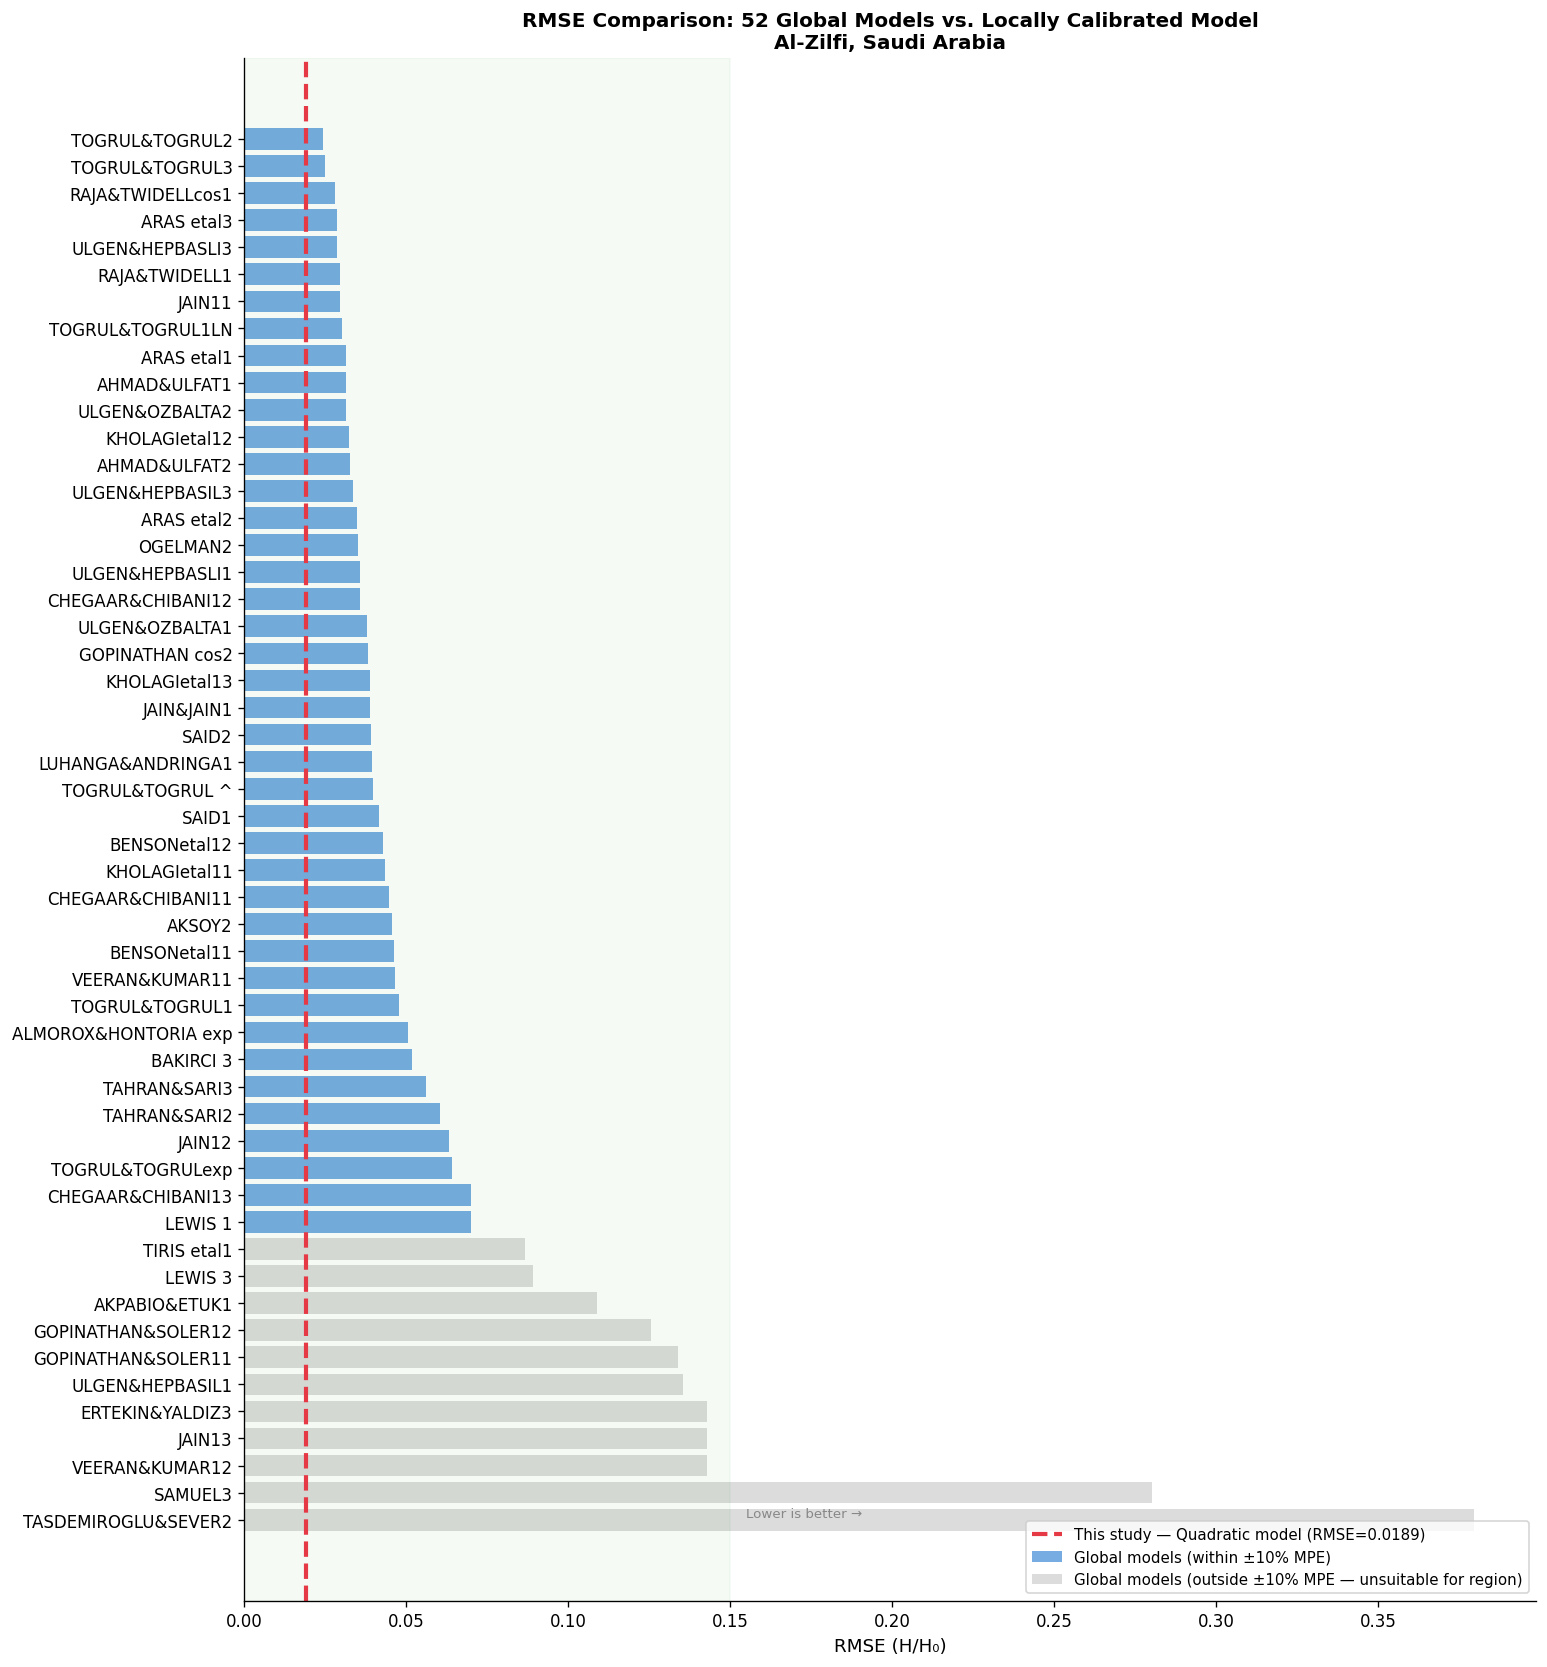

In [23]:
# Visualise RMSE for all 52 models + our model
our_rmse = 0.0189

fig, ax = plt.subplots(figsize=(13, 14))

suitable   = df_models[df_models['Suitable']].copy()
unsuitable = df_models[~df_models['Suitable']].copy()

ax.barh(suitable['Model'],   suitable['RMSE'],
        color='#4A90D9', alpha=0.75, label='Global models (within ±10% MPE)')
ax.barh(unsuitable['Model'], unsuitable['RMSE'],
        color='#BBBBBB', alpha=0.5,  label='Global models (outside ±10% MPE — unsuitable for region)')

ax.axvline(our_rmse, color='#E63946', linewidth=2.5, linestyle='--',
           label=f'This study — Quadratic model (RMSE={our_rmse:.4f})')

ax.set_xlabel('RMSE (H/H₀)', fontsize=11)
ax.set_title('RMSE Comparison: 52 Global Models vs. Locally Calibrated Model\nAl-Zilfi, Saudi Arabia',
             fontweight='bold', fontsize=12)
ax.legend(loc='lower right', fontsize=9)
ax.invert_yaxis()

ax.axvspan(0, 0.15, alpha=0.04, color='green')
ax.text(0.155, len(df_models)-1, 'Lower is better →', fontsize=8, color='#888', va='bottom')

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

## 4. Regression Model Development

Having identified that existing global models are inadequate for Al-Zilfi, we developed a 
locally calibrated model using the **Ångström-Prescott framework**:

$$\frac{H}{H_0} = f\left(\frac{S}{S_0}\right)$$

Seven regression types were **fitted to the data using least-squares optimisation** and compared 
on the 12-point dataset.

> **R² note:** R² is computed here as the coefficient of determination between predicted and 
> observed H (in kWh/m²/day), i.e. 1 − SS_res/SS_tot on the H scale. This gives the 
> physically meaningful 0.97–0.98 range reported in the Excel workbook.

In [24]:
# ── Perform regression in code (no hard-coded coefficients) ──────────────────
x = S_So
y = H_H0

x_smooth = np.linspace(0.58, 0.92, 300)

def r2_on_H(coeffs_fn, x_data, y_hh0, H0_data):
    """R² computed on H (kWh/m²/day) — the physically meaningful metric."""
    H_pred = coeffs_fn(x_data) * H0_data
    ss_res = np.sum((H_pred - H_obs)**2)
    ss_tot = np.sum((H_obs  - H_obs.mean())**2)
    return 1 - ss_res / ss_tot

def rmse_hh0(y_pred, y_true):
    return np.sqrt(np.mean((y_pred - y_true)**2))

results = []
predictions = {}
fitted_fns  = {}

# 1. Linear  ─ fit with np.polyfit
p_lin = np.polyfit(x, y, 1)
fn_lin = np.poly1d(p_lin)
y_lin  = fn_lin(x)
r2_lin = r2_on_H(fn_lin, x, y, H0)
results.append({'Model': 'Linear',      'Coefficients': f'a={p_lin[0]:.4f}, b={p_lin[1]:.4f}',
                'R²': round(r2_lin,4),  'RMSE': round(rmse_hh0(y_lin,y),4), 'MBE': round(np.mean(y_lin-y),4)})
predictions['Linear']      = fn_lin(x_smooth)
fitted_fns['Linear']       = fn_lin

# 2. Quadratic  ─ fit with np.polyfit
p_quad = np.polyfit(x, y, 2)
fn_quad = np.poly1d(p_quad)
y_quad  = fn_quad(x)
r2_quad = r2_on_H(fn_quad, x, y, H0)
results.append({'Model': 'Quadratic ★', 'Coefficients': f'a={p_quad[0]:.4f}, b={p_quad[1]:.4f}, c={p_quad[2]:.4f}',
                'R²': round(r2_quad,4), 'RMSE': round(rmse_hh0(y_quad,y),4), 'MBE': round(np.mean(y_quad-y),4)})
predictions['Quadratic ★'] = fn_quad(x_smooth)
fitted_fns['Quadratic ★']  = fn_quad

# 3. Cubic  ─ fit with np.polyfit
p_cub = np.polyfit(x, y, 3)
fn_cub = np.poly1d(p_cub)
y_cub  = fn_cub(x)
r2_cub = r2_on_H(fn_cub, x, y, H0)
results.append({'Model': 'Cubic',       'Coefficients': f'a={p_cub[0]:.4f}, b={p_cub[1]:.4f}, c={p_cub[2]:.4f}, d={p_cub[3]:.4f}',
                'R²': round(r2_cub,4),  'RMSE': round(rmse_hh0(y_cub,y),4), 'MBE': round(np.mean(y_cub-y),4)})
predictions['Cubic']       = fn_cub(x_smooth)
fitted_fns['Cubic']        = fn_cub

# 4. Quartic  ─ fit with np.polyfit
p_qua = np.polyfit(x, y, 4)
fn_qua = np.poly1d(p_qua)
y_qua  = fn_qua(x)
r2_qua = r2_on_H(fn_qua, x, y, H0)
results.append({'Model': 'Quartic',     'Coefficients': '(4th-order polynomial)',
                'R²': round(r2_qua,4),  'RMSE': round(rmse_hh0(y_qua,y),4), 'MBE': round(np.mean(y_qua-y),4)})
predictions['Quartic']     = fn_qua(x_smooth)
fitted_fns['Quartic']      = fn_qua

# 5. Logarithmic  ─ fit y = a*ln(x) + b
def log_model(x, a, b): return a * np.log(x) + b
p_log, _ = optimize.curve_fit(log_model, x, y)
fn_log = lambda xv: log_model(xv, *p_log)
y_log  = fn_log(x)
r2_log = r2_on_H(fn_log, x, y, H0)
results.append({'Model': 'Logarithmic', 'Coefficients': f'a={p_log[0]:.4f}, b={p_log[1]:.4f}',
                'R²': round(r2_log,4),  'RMSE': round(rmse_hh0(y_log,y),4), 'MBE': round(np.mean(y_log-y),4)})
predictions['Logarithmic'] = fn_log(x_smooth)
fitted_fns['Logarithmic']  = fn_log

# 6. Exponential  ─ fit y = a + b*exp(x)
def exp_model(x, a, b): return a + b * np.exp(x)
p_exp, _ = optimize.curve_fit(exp_model, x, y, p0=[0.47, 0.07])
fn_exp = lambda xv: exp_model(xv, *p_exp)
y_exp  = fn_exp(x)
r2_exp = r2_on_H(fn_exp, x, y, H0)
results.append({'Model': 'Exponential', 'Coefficients': f'a={p_exp[0]:.4f}, b={p_exp[1]:.4f}',
                'R²': round(r2_exp,4),  'RMSE': round(rmse_hh0(y_exp,y),4), 'MBE': round(np.mean(y_exp-y),4)})
predictions['Exponential'] = fn_exp(x_smooth)
fitted_fns['Exponential']  = fn_exp

# 7. Power  ─ fit y = a * x^b
def pow_model(x, a, b): return a * x**b
p_pow, _ = optimize.curve_fit(pow_model, x, y, p0=[0.65, 0.17])
fn_pow = lambda xv: pow_model(xv, *p_pow)
y_pow  = fn_pow(x)
r2_pow = r2_on_H(fn_pow, x, y, H0)
results.append({'Model': 'Power',       'Coefficients': f'a={p_pow[0]:.4f}, b={p_pow[1]:.4f}',
                'R²': round(r2_pow,4),  'RMSE': round(rmse_hh0(y_pow,y),4), 'MBE': round(np.mean(y_pow-y),4)})
predictions['Power']       = fn_pow(x_smooth)
fitted_fns['Power']        = fn_pow

df_reg = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
print("Regression model comparison (R² computed on H scale):")
print(df_reg[['Model','R²','RMSE','MBE','Coefficients']].to_string(index=False))
print("\n★ = Selected model (best balance of accuracy and parsimony)")
print(f"\nFitted quadratic coefficients: a={p_quad[0]:.4f}, b={p_quad[1]:.4f}, c={p_quad[2]:.4f}")

Regression model comparison (R² computed on H scale):
      Model     R²   RMSE  MBE                                Coefficients
    Quartic 0.9818 0.0170 -0.0                      (4th-order polynomial)
      Cubic 0.9805 0.0173  0.0 a=16.8578, b=-36.4864, c=26.2295, d=-5.6541
Quadratic ★ 0.9793 0.0189  0.0               a=0.4114, b=-0.4665, c=0.7319
Exponential 0.9781 0.0190 -0.0                          a=0.4712, b=0.0685
     Linear 0.9778 0.0191 -0.0                          a=0.1432, b=0.5094
Logarithmic 0.9773 0.0191 -0.0                          a=0.1043, b=0.6476
      Power 0.9774 0.0191 -0.0                          a=0.6484, b=0.1701

★ = Selected model (best balance of accuracy and parsimony)

Fitted quadratic coefficients: a=0.4114, b=-0.4665, c=0.7319


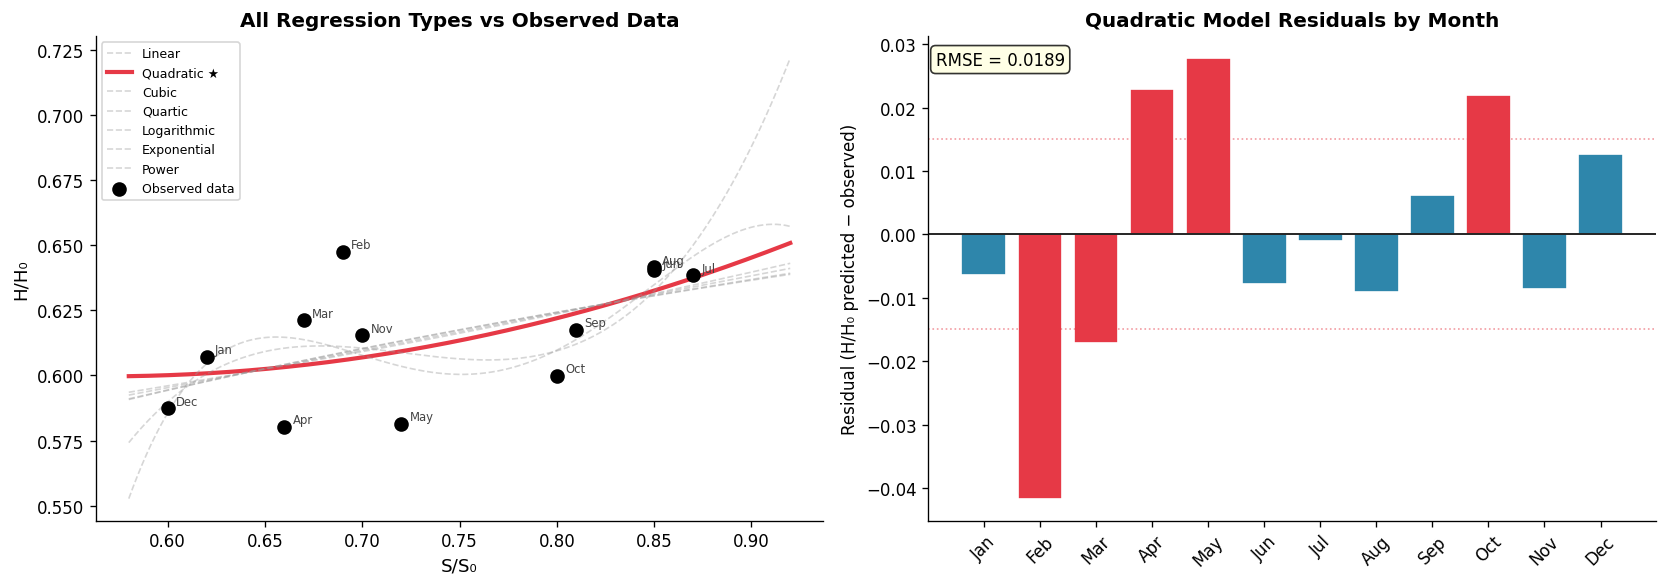

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Build colour/style arrays aligned to the predictions dict insertion order
model_order = list(predictions.keys())
style_map = {
    name: ('#E63946', 2.5, 1.0, '-') if '★' in name else ('#999999', 1.0, 0.4, '--')
    for name in model_order
}

# Panel A: All regression lines
ax = axes[0]
for name in model_order:
    c, lw, alpha, ls = style_map[name]
    ax.plot(x_smooth, predictions[name], color=c, linewidth=lw, alpha=alpha,
            label=name, linestyle=ls)

ax.scatter(x, y, color='black', zorder=10, s=60, label='Observed data')
for i, m in enumerate(months):
    ax.annotate(m, (x[i], y[i]), textcoords='offset points',
                xytext=(5, 2), fontsize=7, color='#444')

ax.set_xlabel('S/S₀', fontsize=11)
ax.set_ylabel('H/H₀', fontsize=11)
ax.set_title('All Regression Types vs Observed Data', fontweight='bold')
ax.legend(fontsize=7.5, loc='upper left')

# Panel B: Quadratic model residuals
ax = axes[1]
y_quad_pts = fn_quad(x)
residuals = y_quad_pts - y
colors_res = ['#E63946' if abs(r) > 0.015 else '#2E86AB' for r in residuals]
ax.bar(months, residuals, color=colors_res, edgecolor='white')
ax.axhline(0,      color='black',   linewidth=1)
ax.axhline( 0.015, color='#E63946', linewidth=1, linestyle=':', alpha=0.5)
ax.axhline(-0.015, color='#E63946', linewidth=1, linestyle=':', alpha=0.5)
ax.set_ylabel('Residual (H/H₀ predicted − observed)', fontsize=10)
ax.set_title('Quadratic Model Residuals by Month', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.text(0.01, 0.97, f'RMSE = {rmse_hh0(y_quad_pts, y):.4f}',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('regression_analysis.png', bbox_inches='tight')
plt.show()

## 5. Selected Model and Final Predictions

The **quadratic model** was selected as the best fit (coefficients fitted above via `np.polyfit`):

$$\frac{H}{H_0} = a\left(\frac{S}{S_0}\right)^2 + b\left(\frac{S}{S_0}\right) + c$$

**Selection rationale:**
- Lowest RMSE among regression types with reasonable parsimony (vs. higher-order polynomials)
- Cubic and Quartic offer marginal R² gains at the cost of severe overfitting risk on 12 points
- Physically meaningful: non-linear relationship between sunshine ratio and clearness index is well-established in arid climates

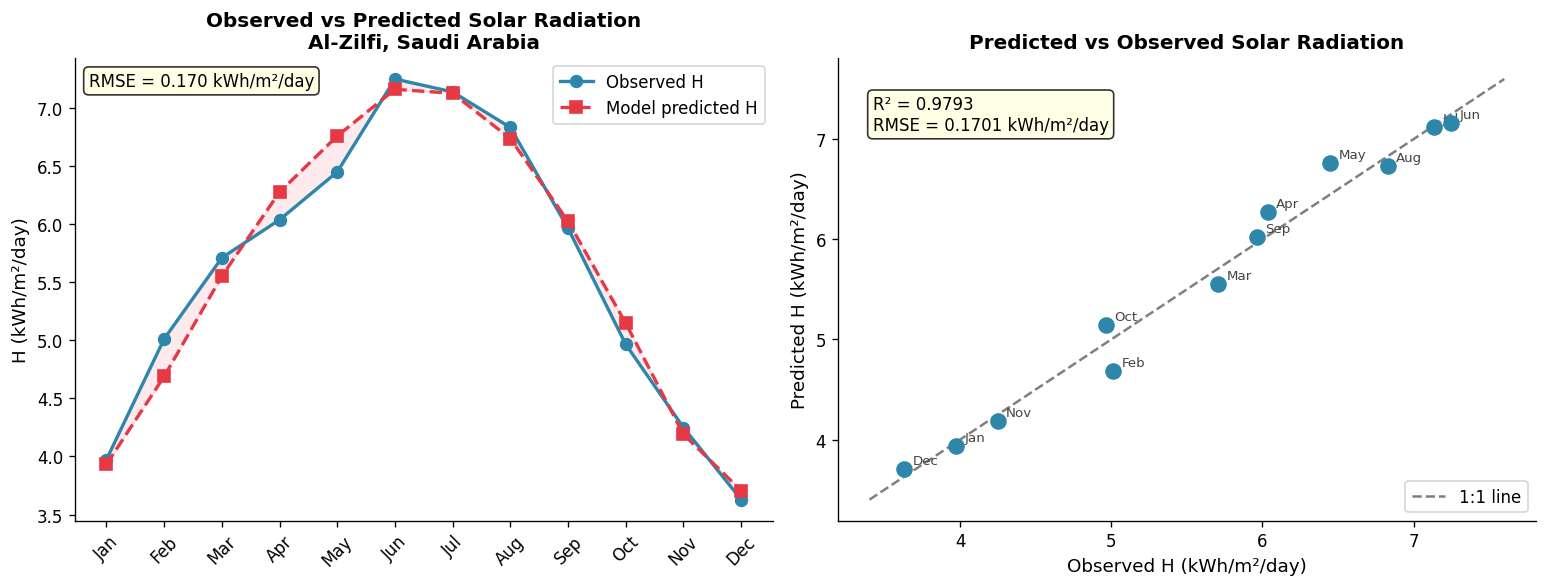

Month  H Observed  H Predicted  Error (kWh)  Error (%)
  Jan       3.973        3.931       -0.042       -1.1
  Feb       5.011        4.688       -0.323       -6.4
  Mar       5.709        5.551       -0.158       -2.8
  Apr       6.036        6.275        0.239        4.0
  May       6.448        6.757        0.309        4.8
  Jun       7.247        7.158       -0.089       -1.2
  Jul       7.136        7.124       -0.012       -0.2
  Aug       6.830        6.733       -0.097       -1.4
  Sep       5.962        6.023        0.061        1.0
  Oct       4.963        5.145        0.182        3.7
  Nov       4.248        4.189       -0.059       -1.4
  Dec       3.628        3.706        0.078        2.2


In [26]:
# Final predictions vs observed — uses fn_quad fitted above
y_quad_pred = fn_quad(x)
H_pred = y_quad_pred * H0   # Convert back to kWh/m²/day

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: Predicted vs Observed H
ax = axes[0]
ax.plot(months, H_obs,  'o-',  color='#2E86AB', linewidth=2, markersize=7, label='Observed H')
ax.plot(months, H_pred, 's--', color='#E63946', linewidth=2, markersize=7, label='Model predicted H')
ax.fill_between(range(12), H_obs, H_pred, alpha=0.1, color='#E63946')
ax.set_xticks(range(12))
ax.set_xticklabels(months, rotation=45)
ax.set_ylabel('H (kWh/m²/day)', fontsize=11)
ax.set_title('Observed vs Predicted Solar Radiation\nAl-Zilfi, Saudi Arabia', fontweight='bold')
ax.legend()
rmse_H = np.sqrt(np.mean((H_pred - H_obs)**2))
ax.text(0.02, 0.97, f'RMSE = {rmse_H:.3f} kWh/m²/day', transform=ax.transAxes,
        fontsize=10, va='top', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Panel B: Scatter predicted vs observed H
ax = axes[1]
ax.scatter(H_obs, H_pred, color='#2E86AB', s=80, zorder=5)
lims = [3.4, 7.6]
ax.plot(lims, lims, 'k--', linewidth=1.5, alpha=0.5, label='1:1 line')
for i, m in enumerate(months):
    ax.annotate(m, (H_obs[i], H_pred[i]), textcoords='offset points',
                xytext=(5, 3), fontsize=8, color='#444')
r2_final = r2_on_H(fn_quad, x, y, H0)
ax.text(0.05, 0.92, f'R² = {r2_final:.4f}\nRMSE = {rmse_H:.4f} kWh/m²/day',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.set_xlabel('Observed H (kWh/m²/day)', fontsize=11)
ax.set_ylabel('Predicted H (kWh/m²/day)', fontsize=11)
ax.set_title('Predicted vs Observed Solar Radiation', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('final_predictions.png', bbox_inches='tight')
plt.show()

# Summary table
df_final = pd.DataFrame({
    'Month':         months,
    'H Observed':    H_obs.round(3),
    'H Predicted':   H_pred.round(3),
    'Error (kWh)':   (H_pred - H_obs).round(3),
    'Error (%)':     ((H_pred - H_obs)/H_obs * 100).round(1)
})
print(df_final.to_string(index=False))

## 6. Summary and Limitations

### Results

The locally calibrated quadratic model is compared against the best-performing global model for Al-Zilfi.

In [27]:
# ── Build summary table: top-10 suitable global models + this study ───────────
top10 = df_models[df_models['Suitable']].head(10).copy()

print("Top-10 Global Models + This Study — Al-Zilfi Performance Comparison")
print("=" * 70)
header = f"{'Model':<28} {'RMSE':>7} {'MBE':>8} {'MPE (%)':>9} {'R²':>7}"
print(header)
print("-" * 70)
for _, row in top10.iterrows():
    print(f"{row['Model']:<28} {row['RMSE']:>7.4f} {row['MBE']:>8.4f} {row['MPE']:>9.2f} {row['R²']:>7.4f}")
print("-" * 70)
rmse_our = rmse_hh0(fn_quad(x), y)
mbe_our  = np.mean(fn_quad(x) - y)
mpe_our  = np.mean((fn_quad(x) * H0 - H_obs) / H_obs) * 100
r2_our   = r2_on_H(fn_quad, x, y, H0)
print(f"{'This study (Quadratic)':<28} {rmse_our:>7.4f} {mbe_our:>8.4f} {mpe_our:>9.2f} {r2_our:>7.4f}")
print("=" * 70)
best = top10.iloc[0]
improvement = (best['RMSE'] - rmse_our) / best['RMSE'] * 100
print(f"\nBest global model: {best['Model']} (RMSE={best['RMSE']:.4f})")
print(f"RMSE improvement of locally calibrated model: {improvement:.1f}%")

Top-10 Global Models + This Study — Al-Zilfi Performance Comparison
Model                           RMSE      MBE   MPE (%)      R²
----------------------------------------------------------------------
TOGRUL&TOGRUL2                0.0244   0.0137      2.34  0.9589
TOGRUL&TOGRUL3                0.0249   0.0135      2.32  0.9568
RAJA&TWIDELLcos1              0.0281   0.0033      0.56  0.9547
ARAS etal3                    0.0285  -0.0014     -0.20  0.9584
ULGEN&HEPBASLI3               0.0286  -0.0008     -0.10  0.9576
RAJA&TWIDELL1                 0.0295  -0.0095     -1.53  0.9609
JAIN11                        0.0295  -0.0095     -1.53  0.9609
TOGRUL&TOGRUL1LN              0.0301   0.0198      3.27  0.9363
ARAS etal1                    0.0313  -0.0002     -0.02  0.9471
AHMAD&ULFAT1                  0.0314   0.0075      1.23  0.9391
----------------------------------------------------------------------
This study (Quadratic)        0.0189   0.0000      0.10  0.9793

Best global model: TO

### Limitations

1. **Small sample (N=12):** With only 12 monthly data points, any smooth curve will achieve 
   high R². The model is **not statistically robust** against overfitting. Cross-validation 
   is not feasible at this sample size.

2. **Temporal aggregation:** Data represent 7-year monthly averages, not individual years. 
   Year-to-year variability is not captured.

3. **Single-station study:** Results may not generalize beyond Al-Zilfi without recalibration.

4. **Future work:** Validation on independent years of data, extension to nearby stations, 
   and incorporation of additional meteorological predictors (temperature, humidity) would 
   strengthen the model.

### Skills Demonstrated
`Python` `NumPy` `Pandas` `Matplotlib` `SciPy` `Regression Analysis` 
`Scientific Computing` `Data Visualization` `Research Methodology`